In [ ]:
# DATA 690 Unit 7 Final Modeling Code
# Target: Overall AQI Value
# Predictors: Original socioeconomic variables with log transforms

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# Load dataset

df = pd.read_csv("/content/country_level_air_pollution_world_bank_2023.csv")

print(df.shape)
print(df.columns)
df.head()

(175, 13)
Index(['Country', 'AQI Value', 'CO AQI Value', 'Ozone AQI Value',
       'NO2 AQI Value', 'PM2.5 AQI Value', 'population_total',
       'population_density', 'urban_population_pct', 'gdp_per_capita',
       'energy_use_per_capita', 'ghg_emissions_per_capita',
       'industry_value_added_pct'],
      dtype='object')


,Country,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,population_total,population_density,urban_population_pct,gdp_per_capita,energy_use_per_capita,ghg_emissions_per_capita,industry_value_added_pct
0,Afghanistan,95.959184,0.591837,40.183673,0.020408,95.918367,41454761.0,63.558501,25.473053,413.757895,NaN,0.782422,13.449823
1,Albania,68.250000,1.000000,42.062500,0.718750,68.093750,2414095.0,88.105657,58.210609,9730.869219,888.463856,3.007835,23.160712
2,Algeria,88.166667,1.916667,47.166667,9.333333,80.250000,46164219.0,19.382560,74.732808,5370.477235,1503.414066,5.609084,37.547655
3,Andorra,29.333333,0.666667,29.333333,0.000000,22.000000,80856.0,172.034043,88.820161,46812.426101,NaN,NaN,12.428226
4,Angola,83.925926,3.148148,22.703704,1.888889,81.925926,36749906.0,29.477746,69.851503,2916.136633,448.870903,1.857986,35.129227


In [ ]:
# Target

target = "AQI Value"

# Start with original socioeconomic variables only

model_df = df[
    [
        target,
        "population_total",
        "population_density",
        "urban_population_pct",
        "gdp_per_capita",
        "energy_use_per_capita",
        "ghg_emissions_per_capita",
        "industry_value_added_pct"
    ]
].dropna().copy()

In [ ]:
# Log-transform skewed predictors

model_df["log_population_total"] = np.log1p(model_df["population_total"])
model_df["log_population_density"] = np.log1p(model_df["population_density"])
model_df["log_gdp_per_capita"] = np.log1p(model_df["gdp_per_capita"])
model_df["log_energy_use"] = np.log1p(model_df["energy_use_per_capita"])
model_df["log_ghg"] = np.log1p(model_df["ghg_emissions_per_capita"])

In [ ]:
# Final original feature set

features = [
    "log_population_total",
    "log_population_density",
    "urban_population_pct",
    "log_gdp_per_capita",
    "log_energy_use",
    "log_ghg",
    "industry_value_added_pct"
]

X = model_df[features]
y = model_df[target]

print("Modeling rows:", model_df.shape[0])
print("Feature count:", len(features))

Modeling rows: 120
Feature count: 7


In [ ]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# Evaluation helper

results = []
fitted_models = {}
predictions_dict = {}

def evaluate_model(name, model, cv_score=None, best_params=None):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    results.append({
        "Model": name,
        "CV_R2": cv_score,
        "Test_R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Best_Params": best_params
    })

    fitted_models[name] = model
    predictions_dict[name] = predictions

    print("\n" + name)
    print("CV R²:", None if cv_score is None else round(cv_score, 3))
    print("Test R²:", round(r2, 3))
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))

    return predictions

In [ ]:
# Model 1: Multiple Linear Regression

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_predictions = evaluate_model(
    "Multiple Linear Regression",
    linear_model
)


Multiple Linear Regression
CV R²: None
Test R²: 0.06
MAE: 23.322
RMSE: 28.581


In [ ]:
# Model 2: Random Forest

rf = RandomForestRegressor(random_state=42)

rf_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 4, 8]
}

rf_search = GridSearchCV(
    estimator=rf,
    param_grid=rf_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best RF Params:", rf_search.best_params_)
print("Best RF CV R²:", rf_search.best_score_)

rf_predictions = evaluate_model(
    "Random Forest",
    rf_search.best_estimator_,
    cv_score=rf_search.best_score_,
    best_params=rf_search.best_params_
)

Best RF Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best RF CV R²: 0.36631307418757686

Random Forest
CV R²: 0.366
Test R²: 0.175
MAE: 21.76
RMSE: 26.761


In [ ]:
# Model 3: Gradient Boosting

gb = GradientBoostingRegressor(random_state=42)

gb_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3]
}

gb_search = GridSearchCV(
    estimator=gb,
    param_grid=gb_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best GB Params:", gb_search.best_params_)
print("Best GB CV R²:", gb_search.best_score_)

gb_predictions = evaluate_model(
    "Gradient Boosting",
    gb_search.best_estimator_,
    cv_score=gb_search.best_score_,
    best_params=gb_search.best_params_
)

Best GB Params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Best GB CV R²: 0.38005247177315327

Gradient Boosting
CV R²: 0.38
Test R²: 0.084
MAE: 22.364
RMSE: 28.214


In [ ]:
# Model comparison table

comparison = pd.DataFrame(results)

comparison_display = comparison[
    ["Model", "CV_R2", "Test_R2", "MAE", "RMSE"]
].sort_values(by="RMSE")

comparison_display

,Model,CV_R2,Test_R2,MAE,RMSE
1,Random Forest,0.366313,0.175489,21.760352,26.760836
2,Gradient Boosting,0.380052,0.083507,22.363888,28.214096
0,Multiple Linear Regression,NaN,0.059517,23.321938,28.580983


In [ ]:
# Champion model

champion = comparison_display.iloc[0]

print("Champion Model:")
print(champion)

Champion Model:
Model      Random Forest
CV_R2           0.366313
Test_R2         0.175489
MAE            21.760352
RMSE           26.760836
Name: 1, dtype: object


In [ ]:
# Publication-friendly labels

feature_labels = {
    "log_population_total": "Log Population",
    "log_population_density": "Log Population Density",
    "urban_population_pct": "Urban Population (%)",
    "log_gdp_per_capita": "Log GDP per Capita",
    "log_energy_use": "Log Energy Use",
    "log_ghg": "Log GHG Emissions",
    "industry_value_added_pct": "Industry Value Added (%)"
}

In [ ]:
# Random Forest feature importance

rf_model = fitted_models["Random Forest"]

rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance["Feature_Label"] = rf_importance["Feature"].map(feature_labels)

rf_importance

,Feature,Importance,Feature_Label
4,log_energy_use,0.212418,Log Energy Use
0,log_population_total,0.203729,Log Population
5,log_ghg,0.180216,Log GHG Emissions
3,log_gdp_per_capita,0.137930,Log GDP per Capita
1,log_population_density,0.129889,Log Population Density
6,industry_value_added_pct,0.094750,Industry Value Added (%)
2,urban_population_pct,0.041068,Urban Population (%)


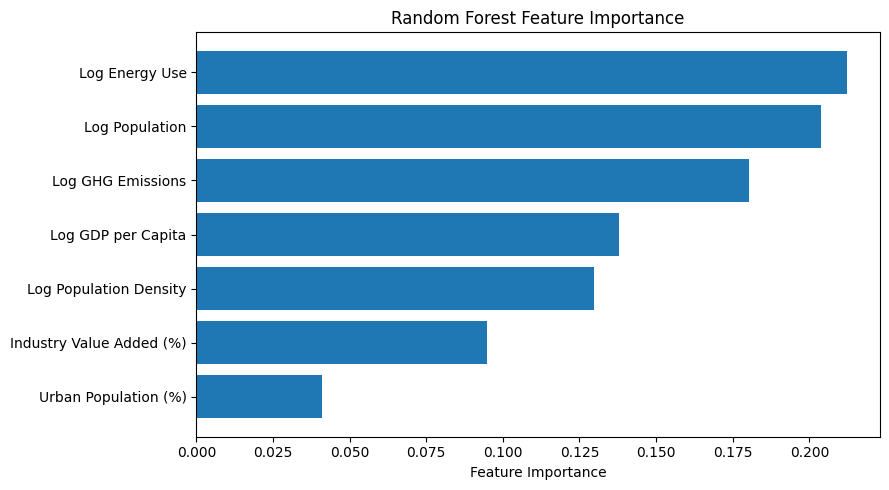

In [ ]:
# Plot Random Forest feature importance

plt.figure(figsize=(9, 5))

plt.barh(
    rf_importance["Feature_Label"],
    rf_importance["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Gradient Boosting feature importance

gb_model = fitted_models["Gradient Boosting"]

gb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

gb_importance["Feature_Label"] = gb_importance["Feature"].map(feature_labels)

gb_importance

,Feature,Importance,Feature_Label
4,log_energy_use,0.237131,Log Energy Use
0,log_population_total,0.196772,Log Population
5,log_ghg,0.194549,Log GHG Emissions
3,log_gdp_per_capita,0.152012,Log GDP per Capita
1,log_population_density,0.137318,Log Population Density
6,industry_value_added_pct,0.061097,Industry Value Added (%)
2,urban_population_pct,0.021120,Urban Population (%)


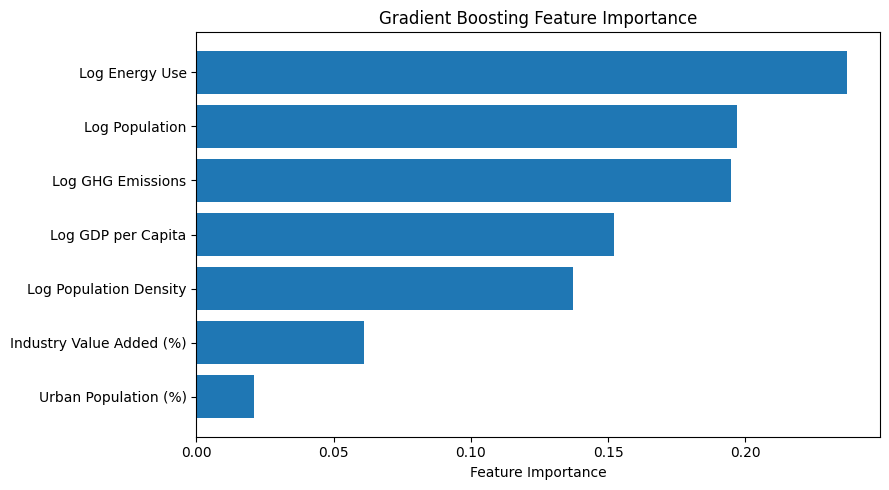

In [ ]:
# Plot Gradient Boosting feature importance

plt.figure(figsize=(9, 5))

plt.barh(
    gb_importance["Feature_Label"],
    gb_importance["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.title("Gradient Boosting Feature Importance")
plt.tight_layout()
plt.show()

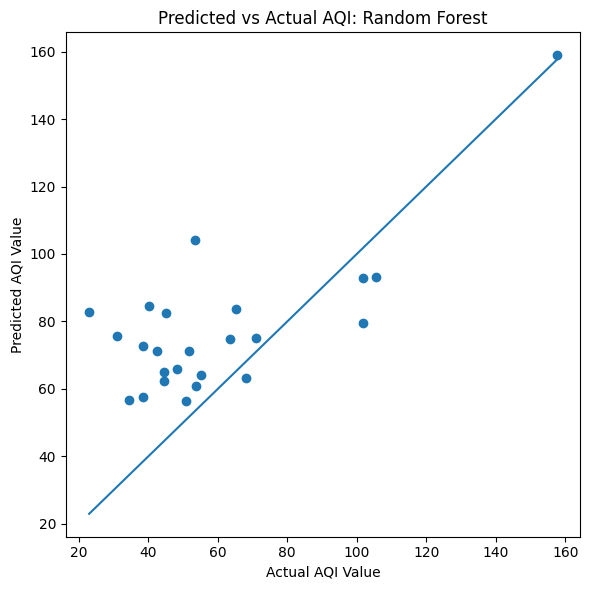

In [ ]:
# Predicted vs Actual for champion model

champion_name = champion["Model"]
champion_predictions = predictions_dict[champion_name]

plt.figure(figsize=(6, 6))

plt.scatter(y_test, champion_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual AQI Value")
plt.ylabel("Predicted AQI Value")
plt.title(f"Predicted vs Actual AQI: {champion_name}")
plt.tight_layout()
plt.show()

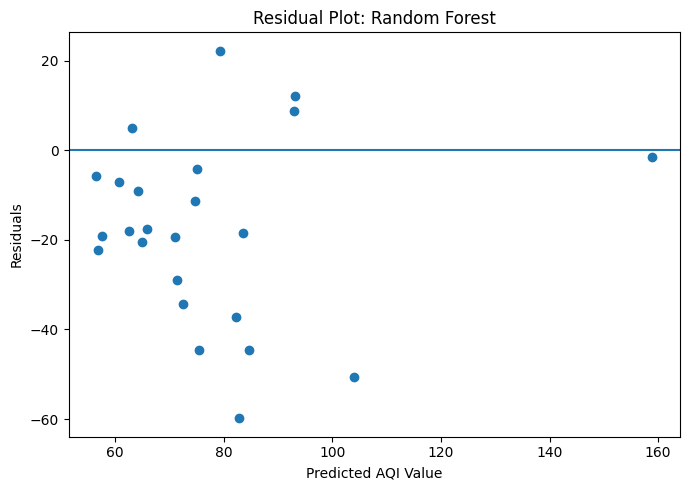

In [ ]:
# Residual plot for champion model

residuals = y_test - champion_predictions

plt.figure(figsize=(7, 5))

plt.scatter(champion_predictions, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted AQI Value")
plt.ylabel("Residuals")
plt.title(f"Residual Plot: {champion_name}")
plt.tight_layout()
plt.show()